In [1]:
#  Import All Required Libraries

import pandas as pd                        # For managing data in table format
import numpy as np                         # For numerical operations
import matplotlib.pyplot as plt            # For plotting graphs
import seaborn as sns                      # For beautiful visualizations
import re                                  # For regex based text cleaning
import string                              # For punctuation removal
import warnings                            # To hide unnecessary warnings
import pickle                              # To save trained models

# NLTK for text processing
import nltk
from nltk.corpus import stopwords          # Common words to remove
from nltk.tokenize import word_tokenize    # Split text into words
from nltk.stem import WordNetLemmatizer    # Convert words to root form

# Scikit-learn for ML
from sklearn.feature_extraction.text import TfidfVectorizer   # Text to numbers
from sklearn.metrics.pairwise import cosine_similarity        # Compare two texts
from sklearn.preprocessing import MinMaxScaler                # Scale scores 0 to 1

# Download required NLTK data
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('punkt_tab')

warnings.filterwarnings('ignore')

print("✅ All libraries imported successfully!")



[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\gupta\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\gupta\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\gupta\AppData\Roaming\nltk_data...
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\gupta\AppData\Roaming\nltk_data...
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\gupta\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.


✅ All libraries imported successfully!


In [2]:
# This is the job role we are hiring for.
# The system will match all resumes against this description.


job_description = """
We are looking for a Machine Learning Engineer with strong Python skills.
The candidate should have experience with scikit-learn, TensorFlow, and PyTorch.
Knowledge of NLP, deep learning, and data preprocessing is required.
Experience with pandas, numpy, matplotlib, and seaborn is expected.
The candidate should know SQL, Git, GitHub, and REST APIs.
Familiarity with computer vision, OpenCV, and model deployment is a plus.
Strong problem solving skills and experience with Jupyter Notebook required.
Knowledge of statistics, probability, and linear algebra is essential.
Experience with AWS or Google Cloud for ML deployment is preferred.
Good communication skills and team collaboration experience needed.
"""

# Define the key skills we expect for this job role
# These are used for skill gap analysis later
required_skills = [
    'python', 'machine learning', 'scikit-learn', 'tensorflow', 'pytorch',
    'nlp', 'deep learning', 'pandas', 'numpy', 'matplotlib', 'seaborn',
    'sql', 'git', 'github', 'rest api', 'computer vision', 'opencv',
    'jupyter', 'statistics', 'probability', 'linear algebra', 'aws',
    'google cloud', 'model deployment', 'data preprocessing', 'keras'
]

print("✅ Job Description defined!")
print(f"📋 Total Required Skills: {len(required_skills)}")


✅ Job Description defined!
📋 Total Required Skills: 26


In [3]:

# Each resume has:
# - name: Candidate name
# - resume_text: Full resume content
# - experience_years: Years of experience


resumes_data = {
    'name': [
        # Strong ML candidates (should rank high)
        'Aarav Sharma', 'Priya Patel', 'Rohit Verma', 'Sneha Gupta', 'Vikram Singh',
        'Ananya Krishnan', 'Arjun Mehta', 'Kavya Nair', 'Rahul Joshi', 'Deepika Rao',

        # Medium ML candidates
        'Amit Kumar', 'Neha Agarwal', 'Siddharth Roy', 'Pooja Mishra', 'Karan Malhotra',
        'Riya Sharma', 'Tarun Gupta', 'Meera Iyer', 'Nikhil Bansal', 'Priyanka Das',

        # Python/Data Science candidates
        'Suresh Reddy', 'Anjali Singh', 'Manish Tiwari', 'Divya Kapoor', 'Rajesh Kumar',
        'Sunita Yadav', 'Aditya Patel', 'Nisha Jain', 'Vivek Sharma', 'Pallavi Gupta',

        # Web/Software developers (low ML skills)
        'Ramesh Nair', 'Geeta Pillai', 'Harish Menon', 'Lakshmi Rao', 'Sunil Verma',
        'Rekha Singh', 'Manoj Kumar', 'Shweta Patel', 'Dinesh Joshi', 'Asha Mehta',

        # Freshers with some ML knowledge
        'Kartik Sharma', 'Bhavna Agarwal', 'Yash Malhotra', 'Kritika Roy', 'Ishaan Gupta',
        'Tanvi Nair', 'Akash Verma', 'Shruti Patel', 'Kunal Singh', 'Manya Joshi',

        # Data analysts
        'Vinod Reddy', 'Smita Kumar', 'Prakash Rao', 'Jyoti Sharma', 'Naveen Patel'
    ],

    'resume_text': [
        # ---- STRONG ML CANDIDATES (ranks 1-10) ----
        # Aarav Sharma
        """Experienced Machine Learning Engineer with 5 years in Python and deep learning.
        Proficient in scikit-learn, TensorFlow, PyTorch, and Keras for model development.
        Strong NLP skills including text classification, named entity recognition.
        Used pandas, numpy, matplotlib, seaborn for data analysis and visualization.
        Experience with SQL databases, Git, GitHub version control, REST APIs.
        Deployed ML models on AWS and Google Cloud platforms.
        Built computer vision projects using OpenCV and convolutional neural networks.
        Expert in data preprocessing, feature engineering, and model evaluation.
        Jupyter Notebook, VS Code for development. Strong statistics and linear algebra background.""",

        # Priya Patel
        """Senior ML Engineer with 6 years experience in machine learning and NLP.
        Deep expertise in Python, TensorFlow, PyTorch, scikit-learn, and Keras.
        Developed NLP pipelines for sentiment analysis, text classification, summarization.
        Worked extensively with pandas, numpy, seaborn, matplotlib for EDA.
        Deployed models using AWS SageMaker and Google Cloud AI Platform.
        Strong background in statistics, probability, and linear algebra.
        Used Git, GitHub for version control and collaborative development.
        Experience with REST APIs, SQL, computer vision using OpenCV.
        Jupyter Notebook power user. Model deployment and optimization expert.""",

        # Rohit Verma
        """Machine Learning Researcher with 4 years Python and deep learning experience.
        Built models using scikit-learn, TensorFlow, PyTorch for classification and regression.
        Specialized in NLP: tokenization, embeddings, transformers, BERT fine-tuning.
        Data analysis with pandas, numpy, matplotlib, seaborn. SQL for data extraction.
        GitHub for version control. Jupyter Notebook for research and experimentation.
        Statistics, probability, linear algebra fundamentals strong.
        AWS deployment experience. REST API development using Flask and FastAPI.
        Computer vision projects using OpenCV and YOLO object detection.""",

        # Sneha Gupta
        """Data Scientist with 3 years in machine learning and Python programming.
        Scikit-learn expert for classification, regression, clustering algorithms.
        NLP projects using NLTK, spaCy, transformers, TF-IDF, word embeddings.
        pandas, numpy, matplotlib, seaborn daily tools for data preprocessing.
        SQL queries for database management. Git, GitHub for code management.
        Jupyter Notebook for analysis. Statistics and probability knowledge strong.
        Model deployment on Google Cloud. REST APIs using Flask.
        Linear algebra, calculus background. Feature engineering specialist.""",

        # Vikram Singh
        """ML Engineer 5 years experience. Python expert. scikit-learn, TensorFlow, PyTorch.
        Deep learning: CNN, RNN, LSTM, Transformer architectures built from scratch.
        NLP pipeline development. Computer vision using OpenCV, YOLO, ResNet.
        pandas, numpy, matplotlib used daily. SQL, NoSQL databases. AWS deployment.
        GitHub, Git version control. REST API, microservices architecture.
        Jupyter Notebook, Google Colab. Statistics, linear algebra, probability.
        Model optimization, hyperparameter tuning, cross validation expert.
        Data preprocessing, feature selection, dimensionality reduction experience.""",

        # Ananya Krishnan
        """AI/ML Engineer with 4 years building production machine learning systems.
        Python, scikit-learn, TensorFlow, Keras, PyTorch for model development.
        NLP: sentiment analysis, text classification, named entity recognition projects.
        Deep learning computer vision with OpenCV and convolutional neural networks.
        pandas, numpy, seaborn, matplotlib for exploratory data analysis.
        AWS SageMaker, Google Cloud for model training and deployment.
        SQL for data querying. Git, GitHub, REST APIs. Jupyter Notebook.
        Statistics, probability, linear algebra. Model evaluation and monitoring.""",

        # Arjun Mehta
        """Machine Learning Developer 3 years. Python scikit-learn TensorFlow PyTorch.
        NLP text mining information extraction sentiment analysis topic modeling.
        Computer vision image classification object detection using OpenCV Keras.
        Data preprocessing feature engineering dimensionality reduction PCA.
        pandas numpy matplotlib seaborn data visualization dashboard creation.
        SQL database management. Git GitHub REST API development Flask.
        AWS cloud deployment. Jupyter Notebook. Statistics probability linear algebra.
        Model deployment monitoring retraining pipeline automation.""",

        # Kavya Nair
        """Senior Data Scientist 5 years machine learning Python deep learning NLP.
        TensorFlow PyTorch scikit-learn Keras model development fine tuning.
        Natural language processing BERT GPT transformers text classification.
        Computer vision OpenCV image segmentation object detection.
        pandas numpy matplotlib seaborn plotly interactive visualization.
        AWS Google Cloud model deployment REST API Flask FastAPI.
        SQL NoSQL Git GitHub Jupyter Notebook statistics linear algebra probability.
        Feature engineering model evaluation cross validation hyperparameter optimization.""",

        # Rahul Joshi
        """ML Engineer with expertise in Python machine learning and deep learning systems.
        scikit-learn TensorFlow PyTorch Keras for classification regression clustering.
        NLP pipeline NLTK spaCy transformers BERT text preprocessing tokenization.
        Data analysis pandas numpy seaborn matplotlib exploratory data analysis.
        Model deployment AWS Google Cloud REST API microservices Docker Kubernetes.
        Git GitHub version control SQL database querying Jupyter Notebook development.
        Statistics probability linear algebra calculus optimization algorithms.
        Computer vision OpenCV CNN feature extraction transfer learning.""",

        # Deepika Rao
        """Applied ML Scientist 6 years Python TensorFlow PyTorch scikit-learn Keras.
        NLP deep learning computer vision model deployment production systems.
        Built recommendation systems fraud detection systems anomaly detection models.
        pandas numpy matplotlib seaborn data preprocessing feature engineering.
        AWS SageMaker Google Cloud AI Platform model training deployment scaling.
        SQL Git GitHub REST API Jupyter Notebook statistics probability linear algebra.
        Computer vision OpenCV image classification segmentation detection.
        Research experience published papers machine learning optimization.""",

        # ---- MEDIUM ML CANDIDATES (ranks 11-20) ----
        # Amit Kumar
        """Data Analyst with 2 years experience in Python and machine learning basics.
        Used scikit-learn for simple classification models. pandas numpy for analysis.
        Basic NLP text preprocessing using NLTK. matplotlib seaborn visualization.
        SQL for data extraction. Git GitHub basics. Jupyter Notebook daily use.
        Statistics and probability knowledge. Basic linear algebra understanding.
        Learning TensorFlow and deep learning. No cloud deployment experience yet.""",

        # Neha Agarwal
        """Python Developer with machine learning interest. 2 years experience.
        scikit-learn models: decision tree, random forest, logistic regression.
        pandas numpy data manipulation. matplotlib visualization. SQL queries.
        Basic NLP using NLTK tokenization stopword removal. Jupyter Notebook.
        Git GitHub. Statistics fundamentals. Learning PyTorch deep learning.
        No production deployment experience. REST API basics with Flask.""",

        # Siddharth Roy
        """Junior ML Engineer fresher. Python scikit-learn pandas numpy matplotlib.
        Academic projects in machine learning: classification regression clustering.
        NLP basics: text preprocessing TF-IDF bag of words sentiment analysis.
        Jupyter Notebook. Git GitHub basics. Statistics probability fundamentals.
        Learning TensorFlow deep learning neural networks. SQL basic queries.
        No real world deployment experience yet. Eager to learn and grow.""",

        # Pooja Mishra
        """Data Science student with Python machine learning projects. Final year.
        scikit-learn classification models. pandas numpy data analysis. matplotlib.
        Basic NLP text classification using NLTK and scikit-learn TF-IDF.
        Jupyter Notebook. Statistics. Git GitHub. SQL basic knowledge.
        Kaggle competitions participant. Learning deep learning TensorFlow.
        Academic projects only. No industry experience. Strong fundamentals.""",

        # Karan Malhotra
        """Software Engineer transitioning to ML. 3 years software development.
        Python scripting. Basic scikit-learn models. pandas numpy data manipulation.
        REST API development Flask Django. SQL databases. Git GitHub expert.
        Learning machine learning NLP deep learning TensorFlow PyTorch.
        Statistics probability basics. Jupyter Notebook. No ML production experience.""",

        # Riya Sharma
        """ML enthusiast with 1 year Python experience. Academic ML projects.
        scikit-learn basic models. pandas numpy matplotlib seaborn. Jupyter Notebook.
        NLP text preprocessing basics NLTK. Statistics fundamentals. Git GitHub.
        SQL basic queries. Learning TensorFlow Keras deep learning computer vision.
        Kaggle datasets practice. No industry experience. Fast learner.""",

        # Tarun Gupta
        """Data Analyst 2 years. Python pandas numpy matplotlib seaborn SQL expert.
        Basic machine learning scikit-learn models for prediction. Jupyter Notebook.
        Statistics probability strong. Git GitHub. Basic NLP text analysis.
        No deep learning experience. No cloud deployment. REST API basics.
        Transitioning from pure analytics to machine learning engineering.""",

        # Meera Iyer
        """Research Assistant ML lab 1.5 years. Python scikit-learn TensorFlow basics.
        Academic NLP projects text classification sentiment analysis NLTK spaCy.
        pandas numpy matplotlib data analysis. Jupyter Notebook. Git GitHub.
        Statistics linear algebra probability strong academic background.
        Learning PyTorch deep learning. SQL basics. No deployment experience.""",

        # Nikhil Bansal
        """Python Developer 2 years with data science skills. pandas numpy matplotlib.
        scikit-learn machine learning models. Basic NLP preprocessing NLTK.
        SQL database queries. Git GitHub version control. Jupyter Notebook.
        Statistics basics. Learning TensorFlow deep learning. REST API Flask.
        No cloud experience. No computer vision. Solid Python fundamentals.""",

        # Priyanka Das
        """Business Analyst with Python and ML skills. 2 years experience.
        pandas numpy data manipulation analysis. matplotlib seaborn visualization.
        scikit-learn basic models for business prediction tasks. SQL expert.
        Statistics probability strong. Jupyter Notebook. Git GitHub.
        Basic NLP text analysis. Learning machine learning deeper concepts.
        No deep learning. No deployment. Business domain knowledge strong.""",

        # ---- PYTHON/DATA SCIENCE CANDIDATES (ranks 21-30) ----
        # Suresh Reddy
        """Python Developer 3 years. pandas numpy matplotlib seaborn expert.
        Data analysis visualization dashboards. SQL databases expert. Git GitHub.
        Basic scikit-learn machine learning. Statistics probability strong.
        Jupyter Notebook. REST API Flask. Basic NLP preprocessing.
        No deep learning TensorFlow PyTorch experience. No cloud deployment.""",

        # Anjali Singh
        """Data Engineer 3 years Python SQL ETL pipelines data warehousing.
        pandas numpy data transformation. matplotlib basic visualization.
        SQL expert. Git GitHub. Basic statistics. Jupyter Notebook basics.
        Learning machine learning scikit-learn basics. No NLP no deep learning.
        AWS basics for data pipelines. REST API. No ML model experience.""",

        # Manish Tiwari
        """Statistics graduate Python R programming. pandas numpy scipy statsmodels.
        Statistical modeling hypothesis testing regression analysis. matplotlib seaborn.
        SQL queries. Jupyter Notebook. Git basics. No deep learning no NLP.
        Basic scikit-learn linear regression logistic regression. Statistics expert.
        Learning machine learning. No production deployment. Academic experience.""",

        # Divya Kapoor
        """Data Visualization Specialist 2 years. matplotlib seaborn plotly tableau.
        Python pandas numpy for data manipulation. SQL databases. Jupyter Notebook.
        Git GitHub basics. Statistics fundamentals. Basic scikit-learn machine learning.
        No NLP no deep learning no cloud deployment. Visualization expert.
        Learning machine learning and Python deeper concepts.""",

        # Rajesh Kumar
        """Backend Developer Python 4 years. Django Flask REST API SQL NoSQL.
        Git GitHub Docker Kubernetes AWS deployment. Python expert.
        No machine learning no NLP no deep learning experience.
        Statistics basics. Jupyter Notebook never used. pandas basic knowledge.
        Transitioning to ML engineering. Strong software engineering background.""",

        # Sunita Yadav
        """Research Analyst 3 years Python R statistics data analysis.
        pandas numpy matplotlib statistical analysis reports. SQL. Jupyter Notebook.
        Git GitHub. Statistics probability linear algebra strong academic background.
        Basic scikit-learn. No deep learning. No NLP. No cloud deployment.
        Academic research publications. Learning machine learning fundamentals.""",

        # Aditya Patel
        """Computer Science fresher with Python machine learning projects.
        scikit-learn basic classification regression. pandas numpy matplotlib.
        Basic NLP NLTK text preprocessing. Jupyter Notebook. Git GitHub. SQL basics.
        Statistics probability fundamentals. Learning TensorFlow deep learning.
        Kaggle competitions. No industry experience. Strong coding skills.""",

        # Nisha Jain
        """MBA graduate with data analytics Python skills. pandas numpy matplotlib.
        SQL expert. Statistics probability strong. Basic scikit-learn machine learning.
        Jupyter Notebook. Git basics. Business intelligence tableau power BI.
        No NLP no deep learning no cloud. Learning machine learning for business.
        Domain knowledge in finance and marketing. No programming depth.""",

        # Vivek Sharma
        """IoT Engineer 3 years Python embedded systems data collection.
        pandas numpy basic data analysis. matplotlib visualization. SQL basics.
        Git GitHub. REST APIs. AWS IoT services. Basic statistics.
        No machine learning no NLP no deep learning. Sensor data experience.
        Transitioning to ML engineering for IoT applications.""",

        # Pallavi Gupta
        """QA Engineer 3 years Python automation testing. pytest selenium.
        Basic Python scripting. Git GitHub. SQL database testing. REST API testing.
        No machine learning no NLP no data science experience.
        Statistics basics. Learning Python data science pandas numpy.
        Transitioning career to data science and machine learning.""",

        # ---- WEB/SOFTWARE DEVELOPERS (ranks 31-40) ----
        # Ramesh Nair
        """Full Stack Developer 4 years JavaScript React Node.js Python basics.
        HTML CSS REST API development. Git GitHub Docker. SQL NoSQL databases.
        AWS deployment. No machine learning no NLP no data science.
        Statistics basics only. No pandas numpy matplotlib scikit-learn.
        Transitioning to backend Python development. No ML experience.""",

        # Geeta Pillai
        """Frontend Developer 3 years React Angular JavaScript TypeScript.
        HTML CSS UI/UX design. Git GitHub. REST API consumption. SQL basics.
        No Python no machine learning no data science no NLP.
        No statistics no linear algebra. Design skills strong. No ML relevance.""",

        # Harish Menon
        """DevOps Engineer 4 years AWS Docker Kubernetes CI/CD pipelines.
        Linux shell scripting Python basics. Git GitHub. REST APIs. SQL basics.
        Infrastructure automation. No machine learning no data science no NLP.
        Statistics basics. No pandas numpy scikit-learn TensorFlow PyTorch.""",

        # Lakshmi Rao
        """Java Developer 5 years Spring Boot microservices REST APIs SQL.
        Git GitHub Maven Jenkins CI/CD. No Python no machine learning.
        No data science no NLP no deep learning. Strong Java OOP skills.
        Statistics basics. Transitioning to Python but no ML experience yet.""",

        # Sunil Verma
        """Android Developer 3 years Java Kotlin mobile app development.
        REST API integration. Git GitHub. SQL local database. No Python.
        No machine learning no data science no NLP no statistics.
        Strong mobile development. No relevance to ML role at all.""",

        # Rekha Singh
        """HR Manager 5 years recruitment talent acquisition people management.
        Excel data analysis. PowerPoint presentations. Basic statistics.
        No Python no machine learning no data science no programming.
        Communication and leadership skills. No technical ML skills.""",

        # Manoj Kumar
        """Network Engineer 4 years Cisco networking CCNA CCNP certification.
        Linux administration Python basic scripting. Git basics. SQL basics.
        No machine learning no data science no NLP no pandas numpy.
        Statistics basics. Infrastructure knowledge. No ML experience.""",

        # Shweta Patel
        """Content Writer 3 years technical writing documentation SEO.
        No programming no Python no machine learning no data science.
        Excel basics. WordPress. Communication skills strong.
        No technical skills relevant to ML role.""",

        # Dinesh Joshi
        """Graphic Designer 4 years Adobe Photoshop Illustrator UI/UX design.
        No Python no programming no machine learning no data science.
        Creative skills. No technical ML relevance whatsoever.""",

        # Asha Mehta
        """Sales Manager 6 years B2B sales CRM Salesforce customer relations.
        Excel data analysis. No Python no programming no machine learning.
        Communication negotiation skills. No technical ML skills at all.""",

        # ---- FRESHERS WITH SOME ML KNOWLEDGE (ranks 41-50) ----
        # Kartik Sharma
        """Computer Science final year. Python pandas numpy matplotlib scikit-learn.
        Machine learning course completed Coursera Andrew Ng certification.
        Basic NLP NLTK text preprocessing. Jupyter Notebook. Git GitHub. SQL basics.
        Statistics probability linear algebra fundamentals. Learning TensorFlow.
        Kaggle beginner. Internship projects machine learning classification.""",

        # Bhavna Agarwal
        """Data Science bootcamp graduate. Python scikit-learn pandas numpy matplotlib.
        Machine learning algorithms classification regression clustering.
        Basic NLP text analysis NLTK. Jupyter Notebook. Git GitHub. SQL basics.
        Statistics probability. Learning deep learning TensorFlow PyTorch.
        Portfolio projects on GitHub. No industry experience. Motivated learner.""",

        # Yash Malhotra
        """BTech Computer Science 2024. Python machine learning projects academic.
        scikit-learn pandas numpy matplotlib seaborn. Jupyter Notebook. Git GitHub.
        NLP basics sentiment analysis text classification NLTK TF-IDF.
        Statistics linear algebra probability. SQL. Learning TensorFlow Keras.
        Kaggle competitions silver medal. Academic excellence. No work experience.""",

        # Kritika Roy
        """MSc Data Science graduate. Python R pandas numpy scipy matplotlib.
        scikit-learn machine learning. Statistics probability linear algebra strong.
        Basic NLP text mining NLTK. Jupyter Notebook. Git GitHub. SQL.
        Thesis on predictive modeling. Learning TensorFlow deep learning.
        Research publications. Academic projects. No industry experience.""",

        # Ishaan Gupta
        """AI enthusiast self taught. Python TensorFlow PyTorch basics scikit-learn.
        pandas numpy matplotlib. NLP basics NLTK text classification projects.
        Jupyter Notebook. Git GitHub. Statistics probability learning.
        SQL basics. Online courses Coursera Udemy deep learning. Kaggle active.
        No formal education in CS. Strong self learning motivation.""",

        # Tanvi Nair
        """Engineering student final semester. Python pandas numpy matplotlib.
        scikit-learn basic models. Machine learning minor project done.
        NLTK basic NLP. Jupyter Notebook. Git GitHub. SQL basics. Statistics.
        Learning deep learning. Coursera ML certification. Kaggle beginner.
        No work experience. Academic projects portfolio on GitHub.""",

        # Akash Verma
        """Recent graduate BSc Statistics. Python R pandas numpy scipy matplotlib.
        Statistics probability linear algebra expert academic background.
        Basic scikit-learn machine learning. SQL. Jupyter Notebook. Git basics.
        Basic NLP. Learning TensorFlow PyTorch deep learning. No industry experience.
        Statistical modeling hypothesis testing regression analysis strength.""",

        # Shruti Patel
        """Fresher MCA graduate. Python pandas numpy matplotlib scikit-learn basics.
        Machine learning course project classification sentiment analysis NLTK.
        Jupyter Notebook. Git GitHub. SQL. Statistics probability fundamentals.
        Learning deep learning TensorFlow. REST API Flask basics.
        No work experience. Internship at small startup Python development.""",

        # Kunal Singh
        """BCA graduate with data science interest. Python basics pandas numpy.
        scikit-learn very basic. matplotlib visualization. Jupyter Notebook.
        Git basics. SQL. Statistics basic. No NLP no deep learning no cloud.
        Learning machine learning from scratch. Online courses in progress.
        Very limited ML knowledge. Beginner level overall.""",

        # Manya Joshi
        """Class 12 pass with Python hobby projects. Basic Python programming.
        No machine learning no pandas no numpy no scikit-learn experience.
        YouTube tutorials Python basics only. No statistics no SQL no Git.
        Not qualified for ML role at all. Very early stage learner.""",

        # ---- DATA ANALYSTS (ranks 51-55) ----
        # Vinod Reddy
        """Senior Data Analyst 4 years Python pandas numpy matplotlib seaborn SQL.
        Statistical analysis hypothesis testing A/B testing experiments.
        Basic scikit-learn regression models for forecasting. Jupyter Notebook.
        Git GitHub. Tableau PowerBI dashboards. Statistics probability expert.
        Basic NLP text analysis. No deep learning. No cloud deployment.""",

        # Smita Kumar
        """Business Intelligence Analyst 3 years SQL Tableau Python pandas numpy.
        matplotlib seaborn data visualization reports. Statistics expert.
        Basic scikit-learn. Jupyter Notebook. Git GitHub. REST API basics.
        No NLP no deep learning no machine learning depth. Analytics focus.""",

        # Prakash Rao
        """Data Analyst 2 years Python pandas numpy matplotlib SQL tableau.
        Basic statistics. Jupyter Notebook. Git basics. scikit-learn very basic.
        No NLP no deep learning no cloud deployment. Analytics role experience.
        Excel expert. PowerPoint reporting. Business domain knowledge.""",

        # Jyoti Sharma
        """Marketing Analyst 2 years Google Analytics Python basics Excel SQL.
        pandas basic data manipulation. matplotlib basic charts. Statistics basics.
        No machine learning no NLP no deep learning no scikit-learn depth.
        Business intelligence focus. Learning Python data science.""",

        # Naveen Patel
        """Financial Analyst 3 years Python pandas numpy Excel SQL finance domain.
        Statistical modeling for finance. matplotlib seaborn charts. Jupyter Notebook.
        Git GitHub. Basic scikit-learn regression. Statistics probability expert.
        No NLP no deep learning no cloud. Finance domain expertise strong."""
    ],

    'experience_years': [
        # Strong ML (5,6,4,3,5,4,3,5,4,6)
        5, 6, 4, 3, 5, 4, 3, 5, 4, 6,
        # Medium ML (2,2,0,0,3,1,2,1,2,2)
        2, 2, 0, 0, 3, 1, 2, 1, 2, 2,
        # Python/DS (3,3,3,2,4,3,0,2,3,3)
        3, 3, 3, 2, 4, 3, 0, 2, 3, 3,
        # Web/Software (4,3,4,5,3,5,4,3,4,6)
        4, 3, 4, 5, 3, 5, 4, 3, 4, 6,
        # Freshers (0,0,0,0,0,0,0,0,0,0)
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        # Analysts (4,3,2,2,3)
        4, 3, 2, 2, 3
    ]
}

# Convert to DataFrame
df = pd.DataFrame(resumes_data)

# Save to CSV
import os
os.makedirs('../data', exist_ok=True)
df.to_csv('../data/resumes.csv', index=False)

print(f"✅ Dataset created with {len(df)} resumes!")
print(f"📊 Dataset Shape: {df.shape}")
print(df[['name', 'experience_years']].head(10))



✅ Dataset created with 55 resumes!
📊 Dataset Shape: (55, 3)
              name  experience_years
0     Aarav Sharma                 5
1      Priya Patel                 6
2      Rohit Verma                 4
3      Sneha Gupta                 3
4     Vikram Singh                 5
5  Ananya Krishnan                 4
6      Arjun Mehta                 3
7       Kavya Nair                 5
8      Rahul Joshi                 4
9      Deepika Rao                 6


In [4]:

# Same cleaning process as Task 2 but applied to resumes


lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    """
    Clean resume text for ML processing.
    Steps: lowercase → remove numbers → remove punctuation
           → tokenize → remove stopwords → lemmatize → rejoin
    """
    text = text.lower()                                          # Lowercase
    text = re.sub(r'\d+', '', text)                             # Remove numbers
    text = text.translate(str.maketrans('', '', string.punctuation))  # Remove punctuation
    tokens = word_tokenize(text)                                 # Split into words
    tokens = [w for w in tokens if w not in stop_words and len(w) > 2]  # Remove stopwords
    tokens = [lemmatizer.lemmatize(w) for w in tokens]          # Lemmatize
    return ' '.join(tokens)                                      # Rejoin

# Apply preprocessing to all resumes and job description
df['cleaned_resume'] = df['resume_text'].apply(preprocess_text)
cleaned_jd = preprocess_text(job_description)

print("✅ Text Preprocessing Complete!")
print(f"\n📝 Sample cleaned resume (Aarav Sharma):")
print(df['cleaned_resume'][0][:300])


✅ Text Preprocessing Complete!

📝 Sample cleaned resume (Aarav Sharma):
experienced machine learning engineer year python deep learning proficient scikitlearn tensorflow pytorch kera model development strong nlp skill including text classification named entity recognition used panda numpy matplotlib seaborn data analysis visualization experience sql database git github 


In [5]:

# We use TF-IDF + Cosine Similarity to measure how similar
# each resume is to the job description.
#
# Cosine Similarity:
# - Score of 1.0 = perfect match (identical content)
# - Score of 0.0 = no match at all (completely different)
# - Higher score = better fit for the job role


# Combine job description with all resumes for TF-IDF fitting
# This ensures JD and resumes share the same vocabulary space
all_texts = [cleaned_jd] + list(df['cleaned_resume'])

# Initialize TF-IDF Vectorizer
tfidf = TfidfVectorizer(
    max_features=1000,   # Use top 1000 important words
    ngram_range=(1, 2),  # Single words + word pairs
    min_df=1,            # Word must appear at least once
    sublinear_tf=True    # Log scaling for better results
)

# Fit and transform all texts to TF-IDF matrix
tfidf_matrix = tfidf.fit_transform(all_texts)

# First row = Job Description vector
jd_vector = tfidf_matrix[0]

# Remaining rows = Resume vectors
resume_vectors = tfidf_matrix[1:]

# Calculate cosine similarity between JD and each resume
# Result is a value between 0 and 1 for each resume
similarity_scores = cosine_similarity(jd_vector, resume_vectors)[0]

# Add similarity scores to dataframe
df['similarity_score'] = similarity_scores

print("✅ TF-IDF Similarity Scoring Complete!")
print(f"\n📊 Score Range: {similarity_scores.min():.3f} to {similarity_scores.max():.3f}")



✅ TF-IDF Similarity Scoring Complete!

📊 Score Range: 0.047 to 0.229


In [6]:

# For each resume, check which required skills are present
# and which are missing (skill gap analysis)


def extract_skills(resume_text, skills_list):
    """
    Check which skills from the required list appear in the resume.

    Args:
        resume_text: Raw resume text
        skills_list: List of required skills for the job

    Returns:
        matched: List of skills found in resume
        missing: List of skills NOT found in resume
        score: Percentage of skills matched (0 to 1)
    """
    resume_lower = resume_text.lower()     # Lowercase for comparison

    matched = []    # Skills found in resume
    missing = []    # Skills not found in resume

    for skill in skills_list:
        if skill.lower() in resume_lower:  # Check if skill appears in resume
            matched.append(skill)
        else:
            missing.append(skill)

    # Calculate skill match percentage
    score = len(matched) / len(skills_list)

    return matched, missing, score


# Apply skill extraction to all resumes
matched_skills_list = []
missing_skills_list = []
skill_scores = []

for resume_text in df['resume_text']:
    matched, missing, score = extract_skills(resume_text, required_skills)
    matched_skills_list.append(matched)
    missing_skills_list.append(missing)
    skill_scores.append(score)

# Add results to dataframe
df['matched_skills'] = matched_skills_list
df['missing_skills'] = missing_skills_list
df['skill_score'] = skill_scores
df['matched_count'] = df['matched_skills'].apply(len)
df['missing_count'] = df['missing_skills'].apply(len)

print("✅ Skill Extraction Complete!")
print(f"\n🏆 Top candidate skills matched: {df['matched_count'].max()}/{len(required_skills)}")
print(f"📉 Lowest skills matched: {df['matched_count'].min()}/{len(required_skills)}")


✅ Skill Extraction Complete!

🏆 Top candidate skills matched: 26/26
📉 Lowest skills matched: 2/26


In [7]:

# Normalize experience years to a 0-1 score
# More years = higher score (capped at 6 years = 1.0)


# Cap experience at 6 years for normalization
max_experience = 6

df['experience_score'] = df['experience_years'].apply(
    lambda x: min(x / max_experience, 1.0)   # Score = years/6, max 1.0
)

print("✅ Experience Scoring Complete!")


✅ Experience Scoring Complete!


In [8]:

# Combine all three scores with weights:
# - Similarity Score : 50% (most important — content match)
# - Skill Score      : 35% (second most important — specific skills)
# - Experience Score : 15% (supporting factor)


# Weight configuration
SIMILARITY_WEIGHT  = 0.50    # 50% weight to content similarity
SKILL_WEIGHT       = 0.35    # 35% weight to skill matching
EXPERIENCE_WEIGHT  = 0.15    # 15% weight to experience

# Calculate final weighted score
df['final_score'] = (
    (df['similarity_score'] * SIMILARITY_WEIGHT) +
    (df['skill_score']      * SKILL_WEIGHT) +
    (df['experience_score'] * EXPERIENCE_WEIGHT)
)

# Convert to percentage for readability
df['final_score_pct'] = (df['final_score'] * 100).round(2)

# Sort candidates by final score (highest first)
df_ranked = df.sort_values('final_score', ascending=False).reset_index(drop=True)

# Assign rank numbers (1 = best candidate)
df_ranked['rank'] = range(1, len(df_ranked) + 1)

print("✅ Final Scoring & Ranking Complete!")
print(f"\n🏆 TOP 10 CANDIDATES:")
print("-" * 65)
print(f"{'Rank':<5} {'Name':<22} {'Score':<8} {'Skills':<10} {'Exp(yrs)'}")
print("-" * 65)
for _, row in df_ranked.head(10).iterrows():
    print(f"{row['rank']:<5} {row['name']:<22} {row['final_score_pct']:<8}% "
          f"{row['matched_count']}/{len(required_skills):<6} {row['experience_years']}")



✅ Final Scoring & Ranking Complete!

🏆 TOP 10 CANDIDATES:
-----------------------------------------------------------------
Rank  Name                   Score    Skills     Exp(yrs)
-----------------------------------------------------------------
1     Deepika Rao            61.43   % 26/26     6
2     Priya Patel            56.35   % 24/26     6
3     Aarav Sharma           54.96   % 24/26     5
4     Kavya Nair             53.73   % 25/26     5
5     Rahul Joshi            52.32   % 25/26     4
6     Ananya Krishnan        51.43   % 24/26     4
7     Arjun Mehta            48.25   % 24/26     3
8     Vikram Singh           47.41   % 21/26     5
9     Rohit Verma            46.8    % 22/26     4
10    Sneha Gupta            40.55   % 19/26     3


In [9]:

# Shortlist = top candidates who meet minimum criteria:
# - Final score >= 40% (good overall match)
# - Skill match >= 30% (knows at least 30% of required skills)


SCORE_THRESHOLD = 0.40     # Minimum final score to be shortlisted
SKILL_THRESHOLD = 0.30     # Minimum skill match percentage

shortlisted = df_ranked[
    (df_ranked['final_score'] >= SCORE_THRESHOLD) &
    (df_ranked['skill_score'] >= SKILL_THRESHOLD)
].copy()

not_shortlisted = df_ranked[
    (df_ranked['final_score'] < SCORE_THRESHOLD) |
    (df_ranked['skill_score'] < SKILL_THRESHOLD)
].copy()

print(f"\n✅ Shortlisting Complete!")
print(f"✅ Shortlisted  : {len(shortlisted)} candidates")
print(f"❌ Not Selected : {len(not_shortlisted)} candidates")

# Save results to CSV
os.makedirs('../data', exist_ok=True)
df_ranked.to_csv('../data/ranked_candidates.csv', index=False)
shortlisted[['rank', 'name', 'final_score_pct', 'matched_count',
             'experience_years']].to_csv('../data/shortlisted.csv', index=False)
print("\n✅ Results saved to CSV files!")




✅ Shortlisting Complete!
✅ Shortlisted  : 10 candidates
❌ Not Selected : 45 candidates

✅ Results saved to CSV files!


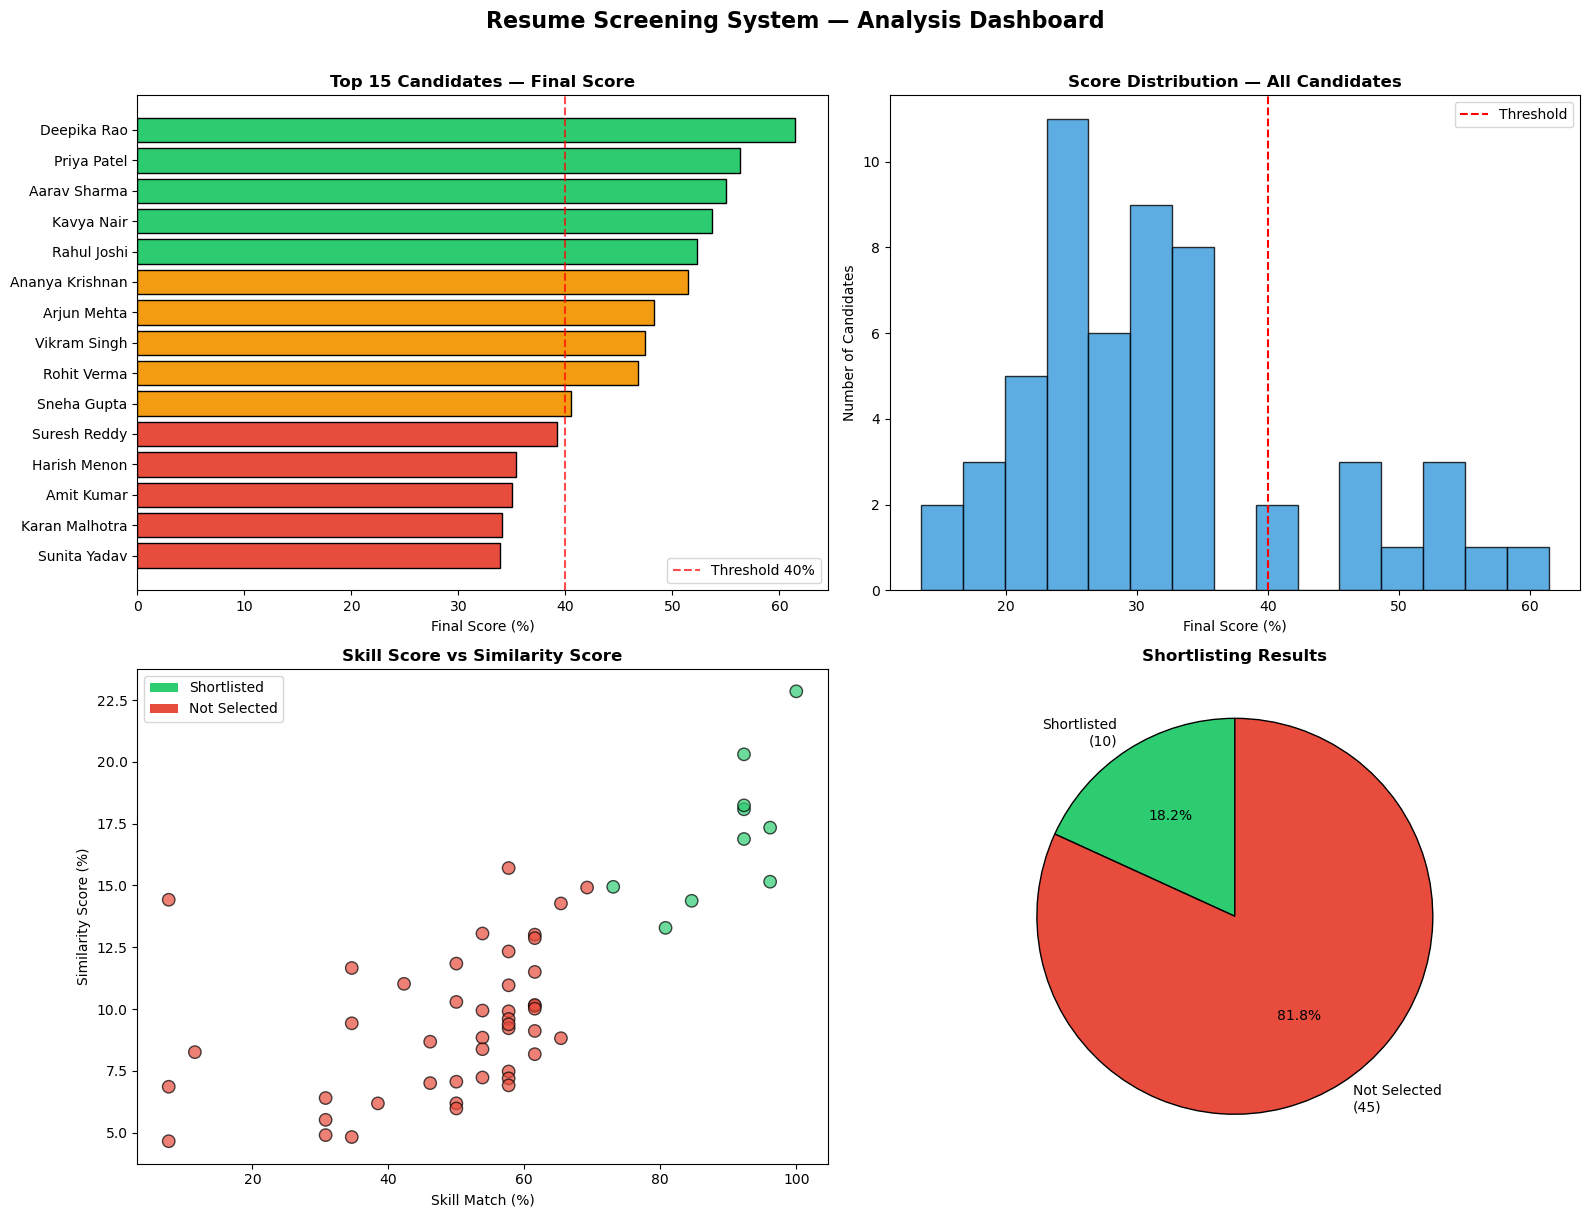

✅ Dashboard saved!


In [10]:
# Visualizations


fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Resume Screening System — Analysis Dashboard',
             fontsize=16, fontweight='bold', y=1.01)

# --- Plot 1: Top 15 candidates by final score ---
top15 = df_ranked.head(15)
colors = ['#2ECC71' if i < 5 else '#F39C12' if i < 10 else '#E74C3C'
          for i in range(15)]

axes[0, 0].barh(top15['name'][::-1], top15['final_score_pct'][::-1],
                color=colors[::-1], edgecolor='black')
axes[0, 0].set_title('Top 15 Candidates — Final Score', fontweight='bold')
axes[0, 0].set_xlabel('Final Score (%)')
axes[0, 0].axvline(x=40, color='red', linestyle='--', alpha=0.7, label='Threshold 40%')
axes[0, 0].legend()

# --- Plot 2: Score distribution histogram ---
axes[0, 1].hist(df_ranked['final_score_pct'], bins=15,
                color='#3498DB', edgecolor='black', alpha=0.8)
axes[0, 1].set_title('Score Distribution — All Candidates', fontweight='bold')
axes[0, 1].set_xlabel('Final Score (%)')
axes[0, 1].set_ylabel('Number of Candidates')
axes[0, 1].axvline(x=40, color='red', linestyle='--', label='Threshold')
axes[0, 1].legend()

# --- Plot 3: Skill match vs Similarity Score scatter ---
scatter_colors = ['#2ECC71' if s >= 0.40 else '#E74C3C'
                  for s in df_ranked['final_score']]
axes[1, 0].scatter(df_ranked['skill_score'] * 100,
                   df_ranked['similarity_score'] * 100,
                   c=scatter_colors, alpha=0.7, s=80, edgecolors='black')
axes[1, 0].set_title('Skill Score vs Similarity Score', fontweight='bold')
axes[1, 0].set_xlabel('Skill Match (%)')
axes[1, 0].set_ylabel('Similarity Score (%)')
# Add legend manually
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#2ECC71', label='Shortlisted'),
                   Patch(facecolor='#E74C3C', label='Not Selected')]
axes[1, 0].legend(handles=legend_elements)

# --- Plot 4: Shortlisted vs Not Shortlisted pie chart ---
sizes = [len(shortlisted), len(not_shortlisted)]
labels = [f'Shortlisted\n({len(shortlisted)})',
          f'Not Selected\n({len(not_shortlisted)})']
colors_pie = ['#2ECC71', '#E74C3C']
axes[1, 1].pie(sizes, labels=labels, colors=colors_pie,
               autopct='%1.1f%%', startangle=90,
               wedgeprops={'edgecolor': 'black'})
axes[1, 1].set_title('Shortlisting Results', fontweight='bold')

plt.tight_layout()
plt.savefig('../data/screening_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Dashboard saved!")



In [11]:
#  Skill Gap Analysis for Top Candidates

# Show what skills the top 5 candidates are missing
# This helps HR understand what training might be needed


print("\n" + "="*60)
print("🔍 SKILL GAP ANALYSIS — TOP 5 CANDIDATES")
print("="*60)

for _, row in df_ranked.head(5).iterrows():
    print(f"\n👤 #{row['rank']} {row['name']} | Score: {row['final_score_pct']}%")
    print(f"   ✅ Matched Skills ({row['matched_count']}): "
          f"{', '.join(row['matched_skills'][:8])}{'...' if len(row['matched_skills']) > 8 else ''}")
    print(f"   ❌ Missing Skills ({row['missing_count']}): "
          f"{', '.join(row['missing_skills'][:5])}{'...' if len(row['missing_skills']) > 5 else ''}")
    print(f"   📅 Experience: {row['experience_years']} years")
    print("-"*60)




🔍 SKILL GAP ANALYSIS — TOP 5 CANDIDATES

👤 #1 Deepika Rao | Score: 61.43%
   ✅ Matched Skills (26): python, machine learning, scikit-learn, tensorflow, pytorch, nlp, deep learning, pandas...
   ❌ Missing Skills (0): 
   📅 Experience: 6 years
------------------------------------------------------------

👤 #2 Priya Patel | Score: 56.35%
   ✅ Matched Skills (24): python, machine learning, scikit-learn, tensorflow, pytorch, nlp, pandas, numpy...
   ❌ Missing Skills (2): deep learning, data preprocessing
   📅 Experience: 6 years
------------------------------------------------------------

👤 #3 Aarav Sharma | Score: 54.96%
   ✅ Matched Skills (24): python, machine learning, scikit-learn, tensorflow, pytorch, nlp, deep learning, pandas...
   ❌ Missing Skills (2): probability, model deployment
   📅 Experience: 5 years
------------------------------------------------------------

👤 #4 Kavya Nair | Score: 53.73%
   ✅ Matched Skills (25): python, machine learning, scikit-learn, tensorflow, pyto

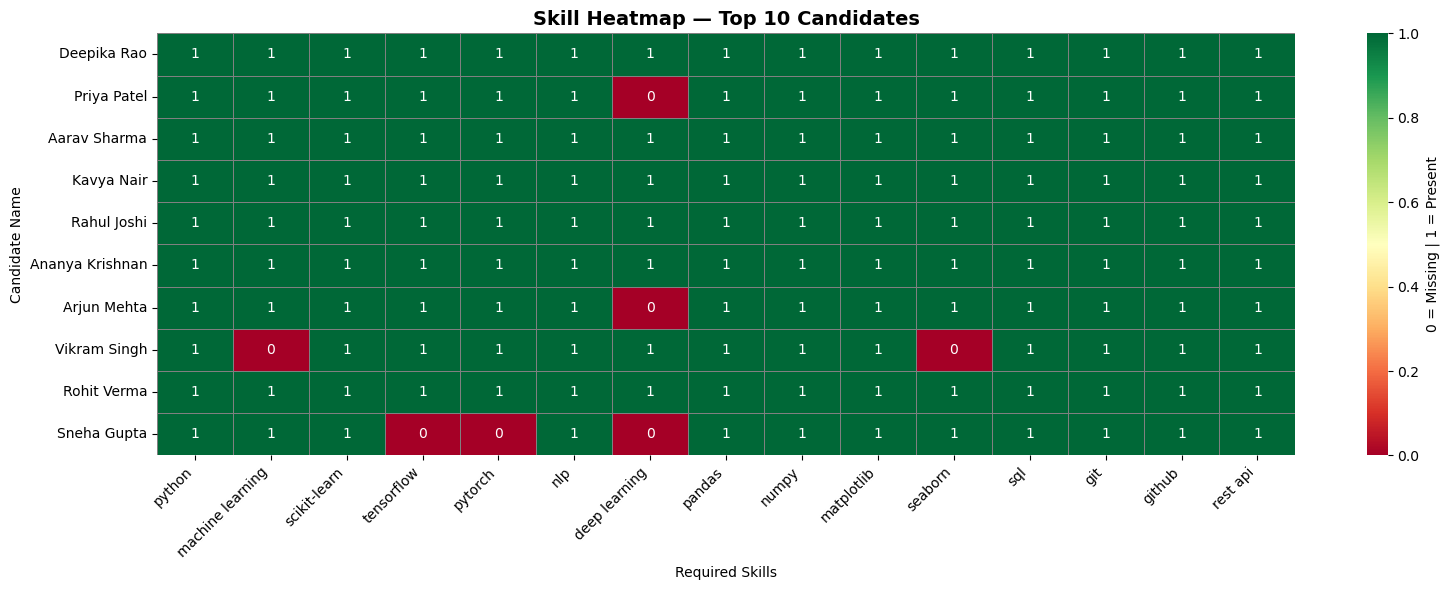

✅ Skill heatmap saved!


In [12]:

# Visualize which skills top 10 candidates have/missing
# Green = has skill, Red = missing skill


top10_candidates = df_ranked.head(10)

# Create skill matrix (1 = has skill, 0 = missing)
skill_matrix = []
for _, row in top10_candidates.iterrows():
    skill_row = [1 if skill in row['matched_skills'] else 0
                 for skill in required_skills[:15]]  # Show first 15 skills
    skill_matrix.append(skill_row)

skill_df = pd.DataFrame(
    skill_matrix,
    index=top10_candidates['name'],
    columns=required_skills[:15]
)

plt.figure(figsize=(16, 6))
sns.heatmap(
    skill_df,
    cmap='RdYlGn',        # Red = missing, Green = present
    annot=True,            # Show 0/1 values in cells
    fmt='d',               # Integer format
    linewidths=0.5,
    linecolor='gray',
    cbar_kws={'label': '0 = Missing | 1 = Present'}
)
plt.title('Skill Heatmap — Top 10 Candidates', fontsize=14, fontweight='bold')
plt.xlabel('Required Skills')
plt.ylabel('Candidate Name')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('../data/skill_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Skill heatmap saved!")



In [13]:
# Save Models


os.makedirs('../model', exist_ok=True)

with open('../model/tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf, f)

print("✅ TF-IDF vectorizer saved to ../model/")



✅ TF-IDF vectorizer saved to ../model/


In [14]:
# Live Resume Screening Function
# Give it any new resume text and get instant results!


def screen_new_resume(candidate_name, resume_text, experience_years):
    """
    Screen a brand new resume against the job description.

    Args:
        candidate_name   : Name of the candidate
        resume_text      : Full resume text
        experience_years : Years of work experience

    Returns:
        Prints complete screening report
    """

    print(f"\n{'='*55}")
    print(f"📄 SCREENING: {candidate_name}")
    print(f"{'='*55}")

    # Step 1: Preprocess resume text
    cleaned = preprocess_text(resume_text)

    # Step 2: TF-IDF similarity with job description
    new_vector = tfidf.transform([cleaned])
    jd_vec = tfidf.transform([cleaned_jd])
    sim_score = cosine_similarity(jd_vec, new_vector)[0][0]

    # Step 3: Skill matching
    matched, missing, skill_score = extract_skills(resume_text, required_skills)

    # Step 4: Experience score
    exp_score = min(experience_years / max_experience, 1.0)

    # Step 5: Final score
    final = (sim_score * 0.50) + (skill_score * 0.35) + (exp_score * 0.15)
    final_pct = round(final * 100, 2)

    # Step 6: Shortlist decision
    decision = "✅ SHORTLISTED" if final >= SCORE_THRESHOLD and skill_score >= SKILL_THRESHOLD \
               else "❌ NOT SELECTED"

    # Print report
    print(f"📊 Similarity Score : {sim_score*100:.1f}%")
    print(f"🎯 Skill Score      : {skill_score*100:.1f}% ({len(matched)}/{len(required_skills)} skills)")
    print(f"📅 Experience Score : {exp_score*100:.1f}% ({experience_years} years)")
    print(f"⭐ FINAL SCORE      : {final_pct}%")
    print(f"🏆 DECISION         : {decision}")
    print(f"\n✅ Matched Skills: {', '.join(matched[:6])}{'...' if len(matched)>6 else ''}")
    print(f"❌ Missing Skills: {', '.join(missing[:6])}{'...' if len(missing)>6 else ''}")
    print(f"{'='*55}")


# Test with 3 new resumes
screen_new_resume(
    "Test Candidate 1",
    """Python developer with machine learning scikit-learn TensorFlow experience.
    NLP projects NLTK pandas numpy matplotlib. Git GitHub. SQL. Jupyter Notebook.
    Statistics probability. AWS deployment. REST API Flask. 3 years experience.""",
    3
)

screen_new_resume(
    "Test Candidate 2",
    """Marketing professional Excel PowerPoint communication skills.
    No programming no Python no machine learning experience at all.""",
    5
)

screen_new_resume(
    "Test Candidate 3",
    """Fresher Python scikit-learn pandas numpy basic ML projects.
    Kaggle beginner. Jupyter Notebook. Git. Statistics basics. Learning TensorFlow.""",
    0
)

print("\n\n🎉 Task 3 Complete!")
print("📁 Files saved in ../data/ and ../model/ folders")



📄 SCREENING: Test Candidate 1
📊 Similarity Score : 14.4%
🎯 Skill Score      : 61.5% (16/26 skills)
📅 Experience Score : 50.0% (3 years)
⭐ FINAL SCORE      : 36.22%
🏆 DECISION         : ❌ NOT SELECTED

✅ Matched Skills: python, machine learning, scikit-learn, tensorflow, nlp, pandas...
❌ Missing Skills: pytorch, deep learning, seaborn, computer vision, opencv, linear algebra...

📄 SCREENING: Test Candidate 2
📊 Similarity Score : 15.3%
🎯 Skill Score      : 7.7% (2/26 skills)
📅 Experience Score : 83.3% (5 years)
⭐ FINAL SCORE      : 22.86%
🏆 DECISION         : ❌ NOT SELECTED

✅ Matched Skills: python, machine learning
❌ Missing Skills: scikit-learn, tensorflow, pytorch, nlp, deep learning, pandas...

📄 SCREENING: Test Candidate 3
📊 Similarity Score : 4.5%
🎯 Skill Score      : 30.8% (8/26 skills)
📅 Experience Score : 0.0% (0 years)
⭐ FINAL SCORE      : 13.01%
🏆 DECISION         : ❌ NOT SELECTED

✅ Matched Skills: python, scikit-learn, tensorflow, pandas, numpy, git...
❌ Missing Skills: ma